In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from feature_extraction import extract_features
from naive_bayes_train import fit_gaussian_naive_bayes
from naive_bayes_predict import predict_gaussian_naive_bayes

In [4]:
img  = cv2.imread('./data/training_image.jpg')
mask = cv2.imread('./data/training_mask.png')[:, :, 0]

print("Extracting features...")
features, H, W = extract_features(img)
labels = mask.flatten()
valid = (labels >= 1) & (labels <= 5)

classes = np.array([1, 2, 3, 4, 5])
print("Training...")
means, variances = fit_gaussian_naive_bayes(features[valid], labels[valid], classes)
log_prior = np.log(np.full(5, 0.2))
print("Done. Means and variances are now in memory.")

Extracting features...
Training...
Done. Means and variances are now in memory.


In [5]:
predictions = predict_gaussian_naive_bayes(features, means, variances, classes, log_prior)
pred_mask = predictions.reshape(H, W)
print("pred_mask is ready, shape:", pred_mask.shape)

pred_mask is ready, shape: (3000, 4000)


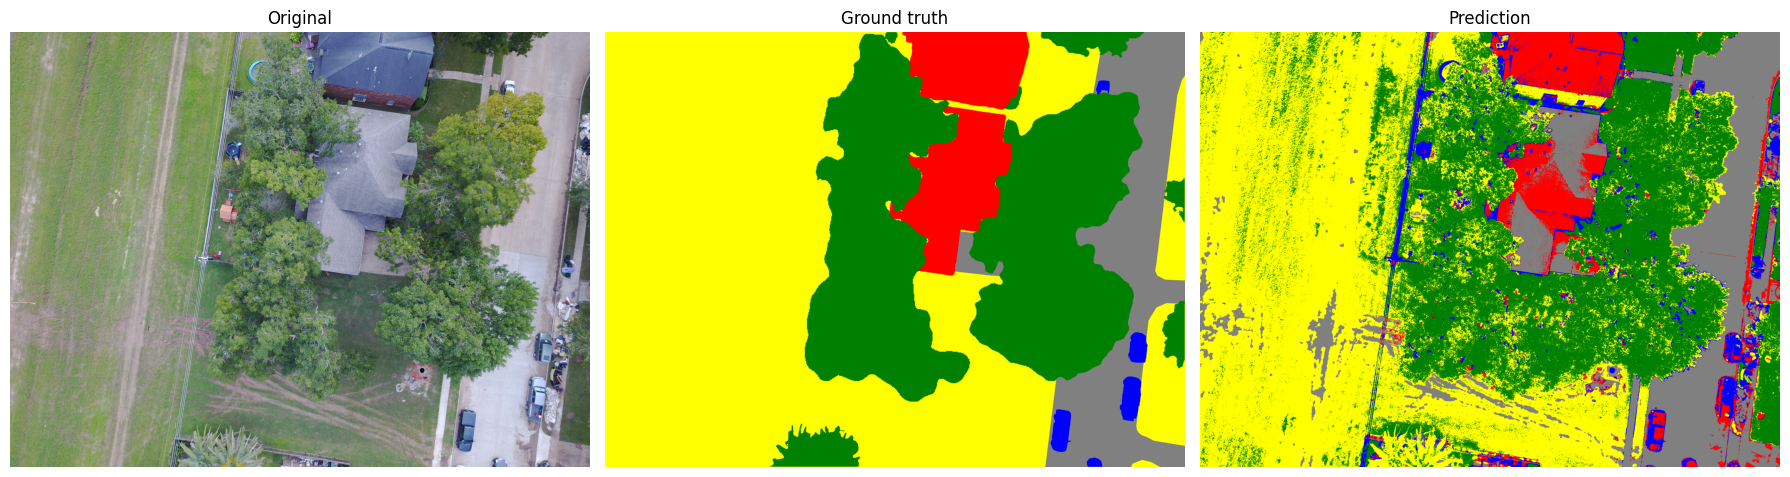

In [6]:
colour_map = {
    1: (255, 0, 0),       # Building - red (RGB this time, for matplotlib)
    2: (128, 128, 128),   # Road
    3: (0, 128, 0),       # Tree
    4: (0, 0, 255),       # Vehicle
    5: (255, 255, 0),     # Grass
}

def colourise(label_mask):
    out = np.zeros((*label_mask.shape, 3), dtype=np.uint8)
    for label, c in colour_map.items():
        out[label_mask == label] = c
    return out

# Convert OpenCV BGR image to RGB for matplotlib display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb);                    axes[0].set_title("Original");     axes[0].axis('off')
axes[1].imshow(colourise(mask));            axes[1].set_title("Ground truth"); axes[1].axis('off')
axes[2].imshow(colourise(pred_mask));       axes[2].set_title("Prediction");   axes[2].axis('off')
plt.tight_layout()
plt.show()

In [10]:
from scipy.ndimage import median_filter
import time

# Try several filter sizes and compare
for filter_size in [5, 9, 15, 21, 31]:
    t0 = time.time()
    clean_mask = median_filter(pred_mask, size=filter_size)
    elapsed = time.time() - t0

    clean_predictions = clean_mask.flatten()
    recalls_after = []
    for k in classes:
        truth = (labels == k)
        if truth.sum() == 0: continue
        tp = ((clean_predictions == k) & truth).sum()
        recalls_after.append(tp / truth.sum())
    bal_acc = np.mean(recalls_after) * 100

    # Per-class for the most informative ones
    print(f"size={filter_size:>3d}: balanced_acc={bal_acc:5.2f}%, "
          f"vehicle_recall={recalls_after[3]*100:5.1f}%, "
          f"time={elapsed:.1f}s")

size=  5: balanced_acc=73.16%, vehicle_recall= 64.4%, time=0.5s
size=  9: balanced_acc=74.02%, vehicle_recall= 65.3%, time=1.6s
size= 15: balanced_acc=74.73%, vehicle_recall= 65.2%, time=4.1s
size= 21: balanced_acc=75.21%, vehicle_recall= 64.6%, time=7.7s
size= 31: balanced_acc=75.70%, vehicle_recall= 63.7%, time=15.9s


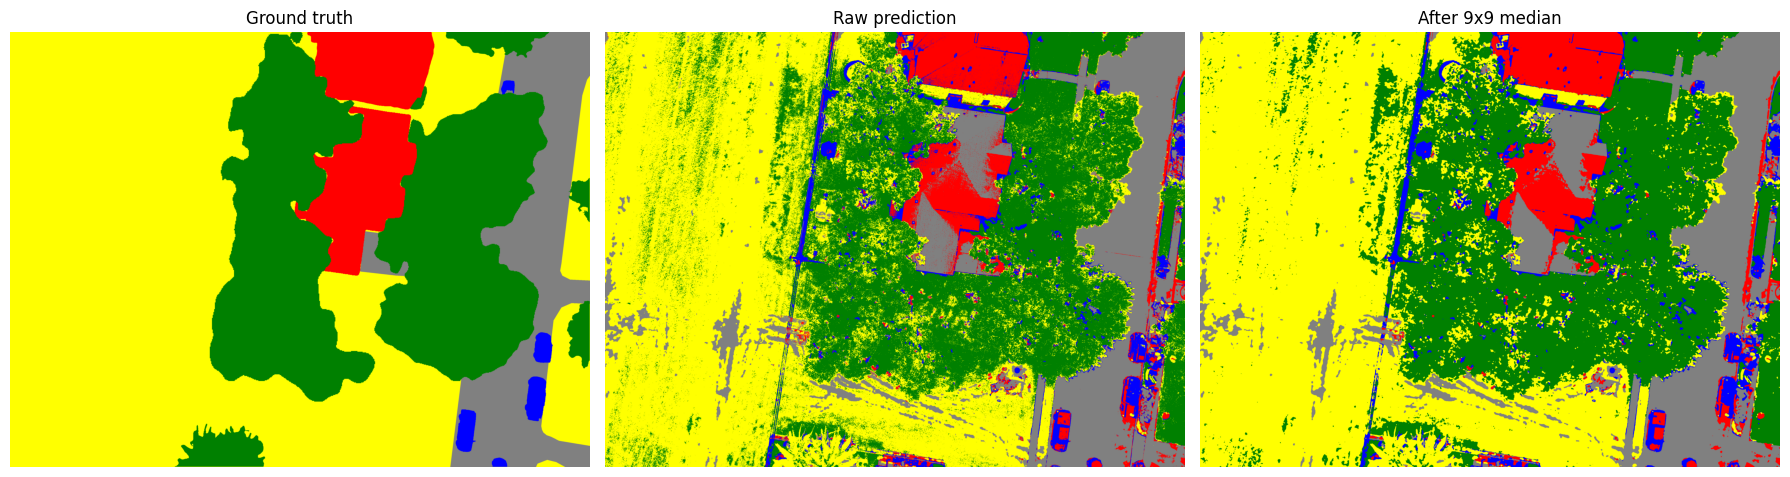

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(colourise(mask));         axes[0].set_title("Ground truth"); axes[0].axis('off')
axes[1].imshow(colourise(pred_mask));    axes[1].set_title("Raw prediction");      axes[1].axis('off')
axes[2].imshow(colourise(clean_mask));   axes[2].set_title(f"After {filter_size}x{filter_size} median"); axes[2].axis('off')
plt.tight_layout()
plt.show()

In [12]:
from scipy.ndimage import median_filter

# Try a 9x9 median filter
filter_size = 15
clean_mask = median_filter(pred_mask, size=filter_size)

# Re-evaluate balanced accuracy
clean_predictions = clean_mask.flatten()
recalls_after = []
print(f"=== After median filter (size={filter_size}) ===")
for k in classes:
    truth = (labels == k)
    if truth.sum() == 0: continue
    tp = ((clean_predictions == k) & truth).sum()
    r = tp / truth.sum()
    recalls_after.append(r)
    print(f"  Recall[{class_names[k]:<8s}] = {r*100:5.1f}%")
print(f"\n  Balanced accuracy: {np.mean(recalls_after)*100:.2f}%")

=== After median filter (size=15) ===
  Recall[Building] =  61.8%
  Recall[Road    ] =  92.3%
  Recall[Tree    ] =  82.1%
  Recall[Vehicle ] =  65.2%
  Recall[Grass   ] =  72.3%

  Balanced accuracy: 74.73%


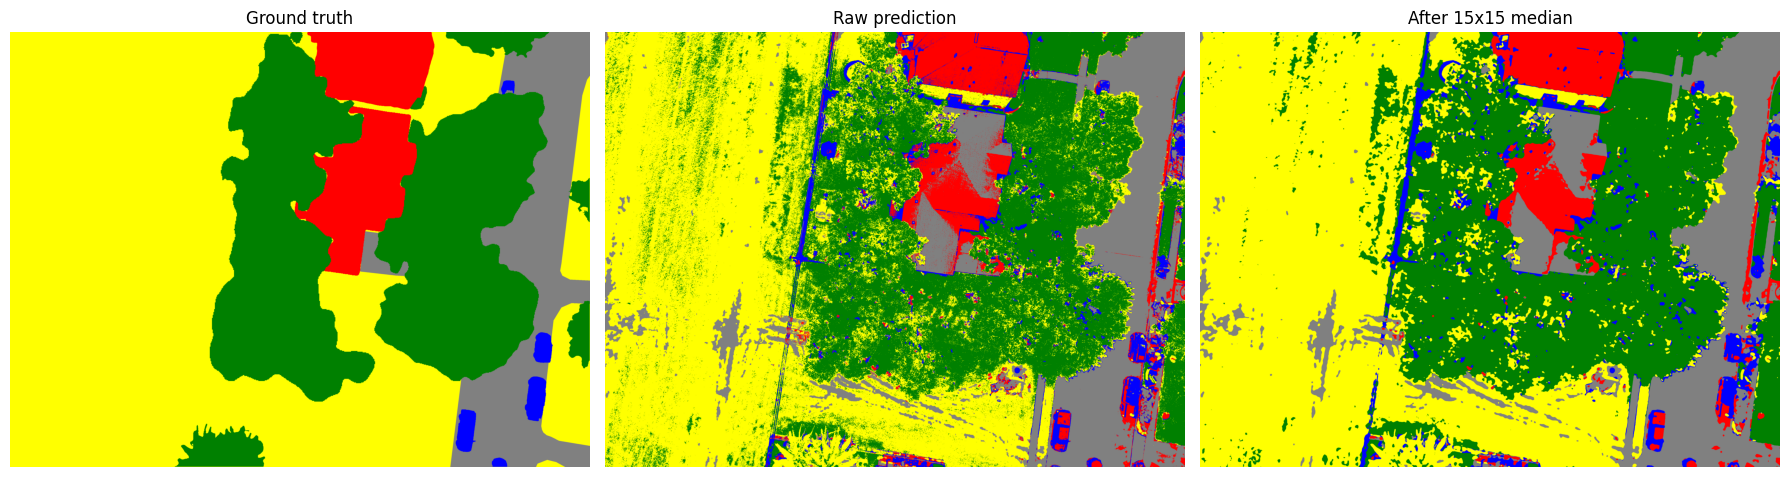

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(colourise(mask));         axes[0].set_title("Ground truth"); axes[0].axis('off')
axes[1].imshow(colourise(pred_mask));    axes[1].set_title("Raw prediction");      axes[1].axis('off')
axes[2].imshow(colourise(clean_mask));   axes[2].set_title(f"After {filter_size}x{filter_size} median"); axes[2].axis('off')
plt.tight_layout()
plt.show()

In [14]:
from scipy.ndimage import median_filter

# Re-run the filter cleanly
test_clean_15 = median_filter(pred_mask, size=15)

# How many pixels actually changed?
n_changed = (test_clean_15 != pred_mask).sum()
total = pred_mask.size
print(f"Pixels changed by 15x15 median: {n_changed:,} / {total:,} "
      f"({100*n_changed/total:.1f}%)")

# And recompute balanced accuracy
test_flat = test_clean_15.flatten()
recalls = []
for k in classes:
    truth = (labels == k)
    tp = ((test_flat == k) & truth).sum()
    recalls.append(tp / truth.sum())
print(f"Balanced accuracy at 15x15: {np.mean(recalls)*100:.2f}%")

Pixels changed by 15x15 median: 1,241,970 / 12,000,000 (10.3%)
Balanced accuracy at 15x15: 74.73%


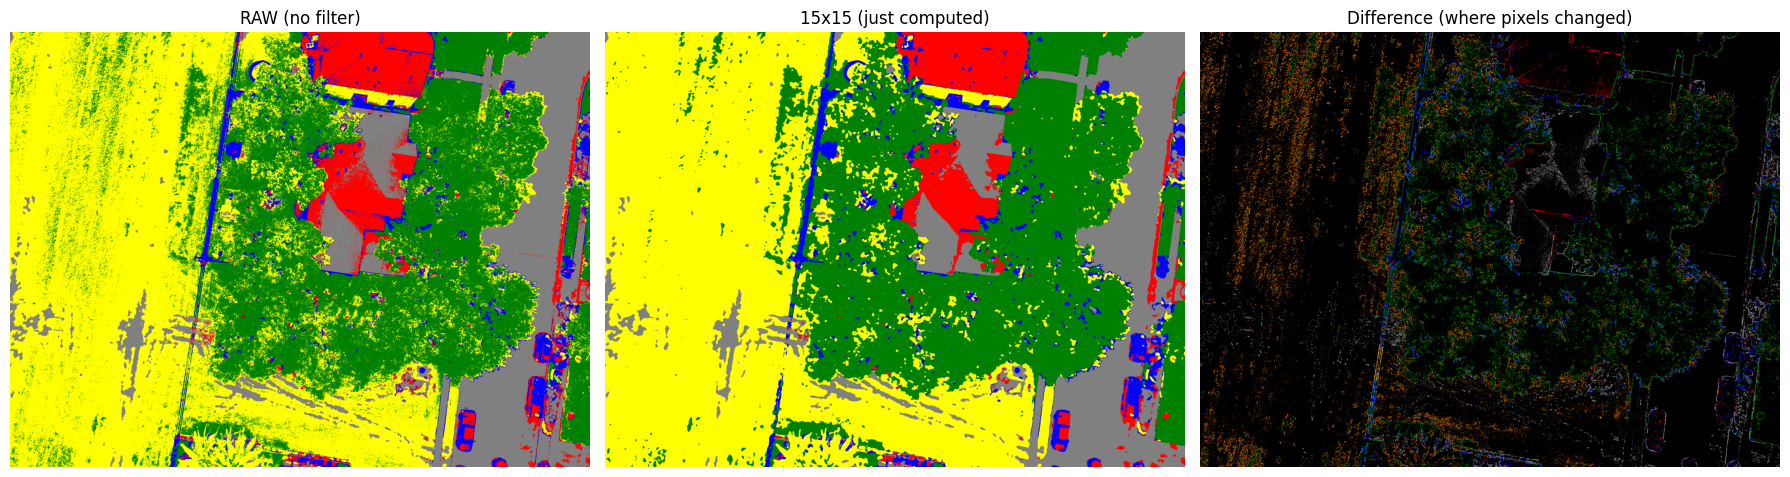

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(colourise(pred_mask));     axes[0].set_title("RAW (no filter)");        axes[0].axis('off')
axes[1].imshow(colourise(test_clean_15)); axes[1].set_title("15x15 (just computed)");  axes[1].axis('off')
axes[2].imshow(colourise(test_clean_15) - colourise(pred_mask)); 
axes[2].set_title("Difference (where pixels changed)"); axes[2].axis('off')
plt.tight_layout()
plt.show()

In [21]:
from scipy.ndimage import median_filter

def predict_and_save(image_filename, output_filename, 
                     means, variances, classes, log_prior, 
                     filter_size=21):
    """Run the full pipeline on a test image and save the predicted mask."""
    
    # Load
    img = cv2.imread(image_filename)
    if img is None:
        raise FileNotFoundError(f"Could not read {image_filename}")
    print(f"Loaded {image_filename}, shape={img.shape}")
    
    # Features
    print("  Extracting features...")
    features, H, W = extract_features(img)
    
    # Predict
    print("  Predicting...")
    predictions = predict_gaussian_naive_bayes(
        features, means, variances, classes, log_prior)
    raw_mask = predictions.reshape(H, W).astype(np.uint8)
    
    # Post-process
    print(f"  Applying {filter_size}x{filter_size} median filter...")
    clean_mask = median_filter(raw_mask, size=filter_size).astype(np.uint8)
    
    # Save in 3-channel format (the brief requires this)
    mask_3ch = np.stack([clean_mask, clean_mask, clean_mask], axis=-1)
    cv2.imwrite(output_filename, mask_3ch)
    print(f"  Saved {output_filename}")
    
    return clean_mask, img

# Run on both test images
clean_test1, img_test1 = predict_and_save(
    './data/testing_image1.jpg', './data/testing_generated_mask1.png',
    means, variances, classes, log_prior, filter_size=21)

clean_test2, img_test2 = predict_and_save(
    './data/testing_image2.jpg', './data/testing_generated_mask2.png',
    means, variances, classes, log_prior, filter_size=21)

print("\nDone! testing_mask1.png and testing_mask2.png are saved.")

Loaded ./data/testing_image1.jpg, shape=(3000, 4000, 3)
  Extracting features...
  Predicting...
  Applying 21x21 median filter...
  Saved ./data/testing_generated_mask1.png
Loaded ./data/testing_image2.jpg, shape=(3000, 4000, 3)
  Extracting features...
  Predicting...
  Applying 21x21 median filter...
  Saved ./data/testing_generated_mask2.png

Done! testing_mask1.png and testing_mask2.png are saved.


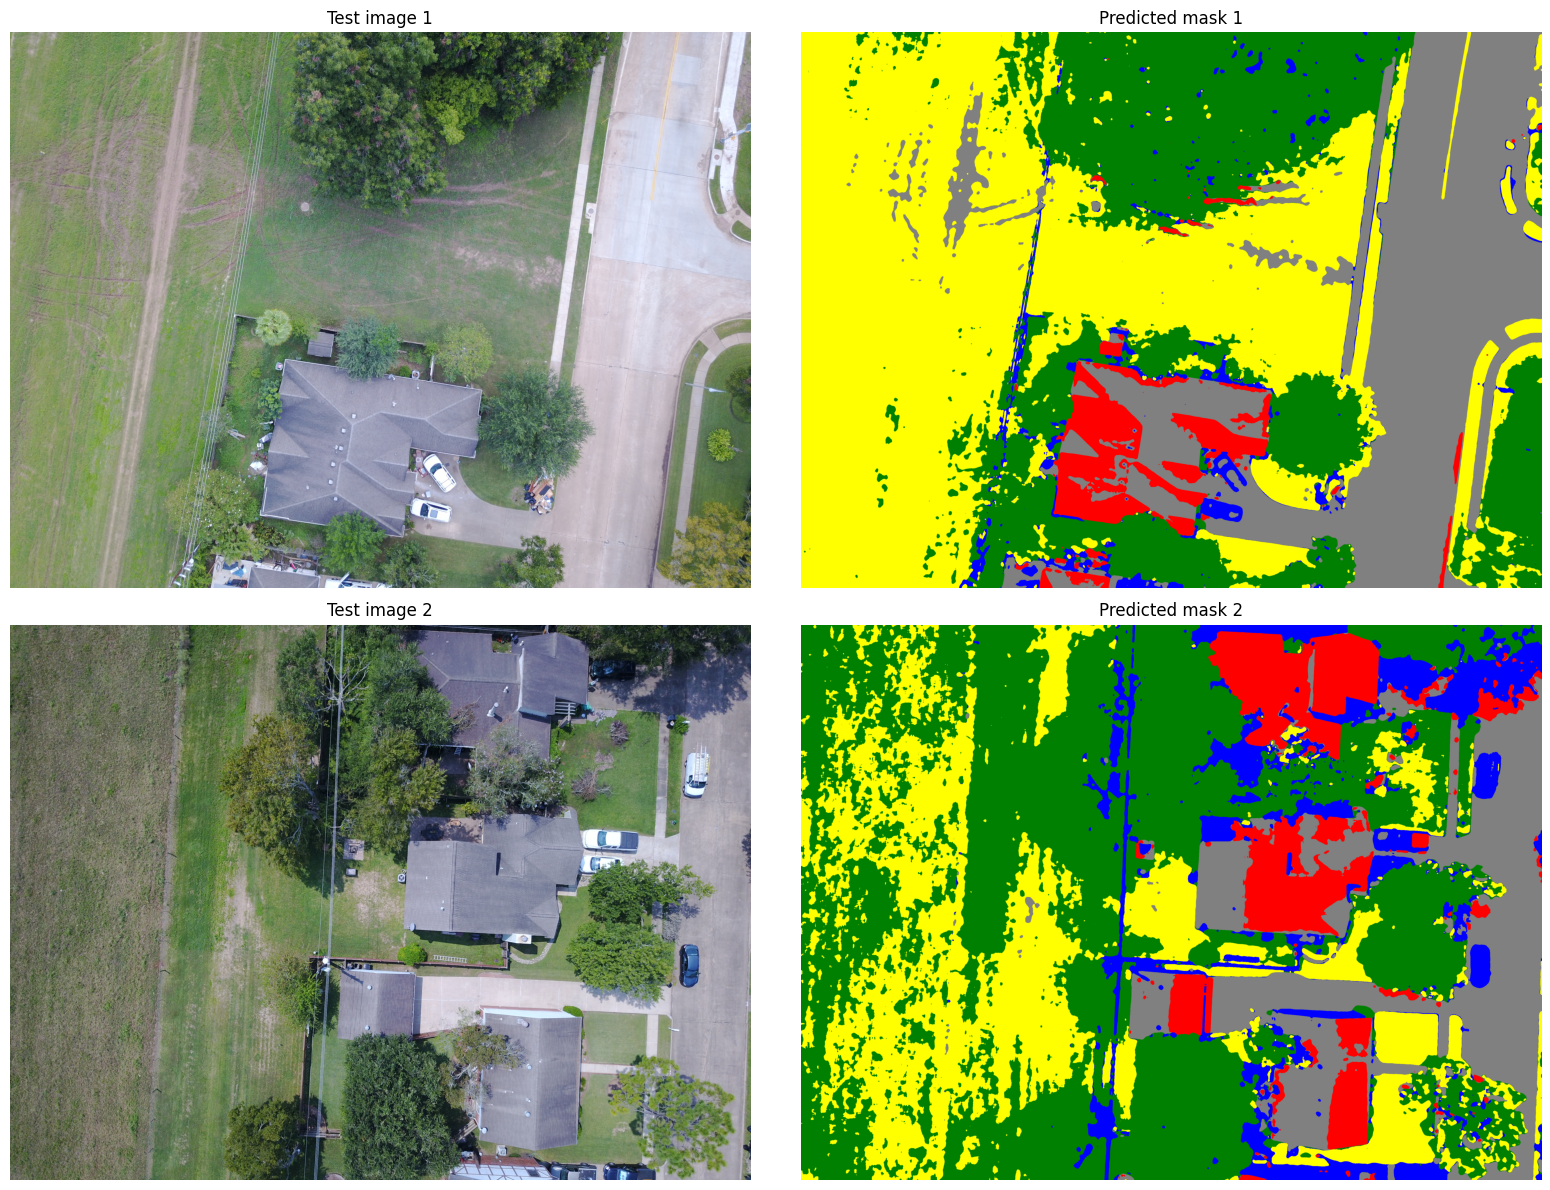

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test image 1
axes[0,0].imshow(cv2.cvtColor(img_test1, cv2.COLOR_BGR2RGB))
axes[0,0].set_title("Test image 1");                axes[0,0].axis('off')
axes[0,1].imshow(colourise(clean_test1))
axes[0,1].set_title("Predicted mask 1");            axes[0,1].axis('off')

# Test image 2
axes[1,0].imshow(cv2.cvtColor(img_test2, cv2.COLOR_BGR2RGB))
axes[1,0].set_title("Test image 2");                axes[1,0].axis('off')
axes[1,1].imshow(colourise(clean_test2))
axes[1,1].set_title("Predicted mask 2");            axes[1,1].axis('off')

plt.tight_layout()
plt.show()

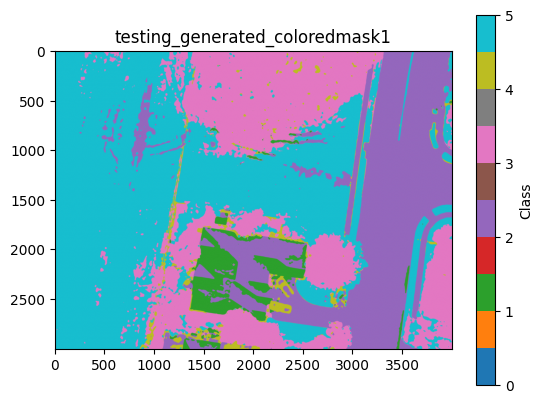

In [24]:
import cv2
import matplotlib.pyplot as plt

mask = cv2.imread('./data/testing_generated_mask1.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(mask, cmap='tab10', vmin=0, vmax=5)
plt.colorbar(label='Class')
plt.title('testing_generated_coloredmask1')
plt.show()